In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

ValueError: Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template']

In [4]:
bee_data = pd.read_csv("bee_data.csv")
print(bee_data.head())
print(bee_data.shape)

          file     date   time        location  zip code subspecies  \
0  041_066.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
1  041_072.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
2  041_073.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
3  041_067.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   
4  041_059.png  8/28/18  16:07  Alvin, TX, USA     77511         -1   

              health  pollen_carrying   caste  
0  hive being robbed            False  worker  
1  hive being robbed            False  worker  
2  hive being robbed            False  worker  
3  hive being robbed            False  worker  
4  hive being robbed            False  worker  
(5172, 9)


In [6]:
# Separate features (X) and target (y)
X = bee_data.drop('health', axis=1)
y = bee_data['health']

# Split data randomly into train (80%) and test (20%)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dataset shapes
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Number of unique classes
num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")
print(np.unique(y_train))

x_train shape: (4137, 8)
y_train shape: (4137,)
x_test shape: (1035, 8)
y_test shape: (1035,)
Number of classes: 6
['Varroa, Small Hive Beetles' 'ant problems' 'few varrao, hive beetles'
 'healthy' 'hive being robbed' 'missing queen']


In [21]:
from PIL import Image
import os

# Function to load an image from the bee_imgs folder
def load_image(filename):
    img_path = os.path.join("bee_imgs", filename)
    return np.array(Image.open(img_path))

In [22]:
# Load all images from the training set as a list
x_train_images = [load_image(x_train.iloc[i, 0]) for i in range(len(x_train))]
print(f"Loaded {len(x_train_images)} images")

Loaded 4137 images


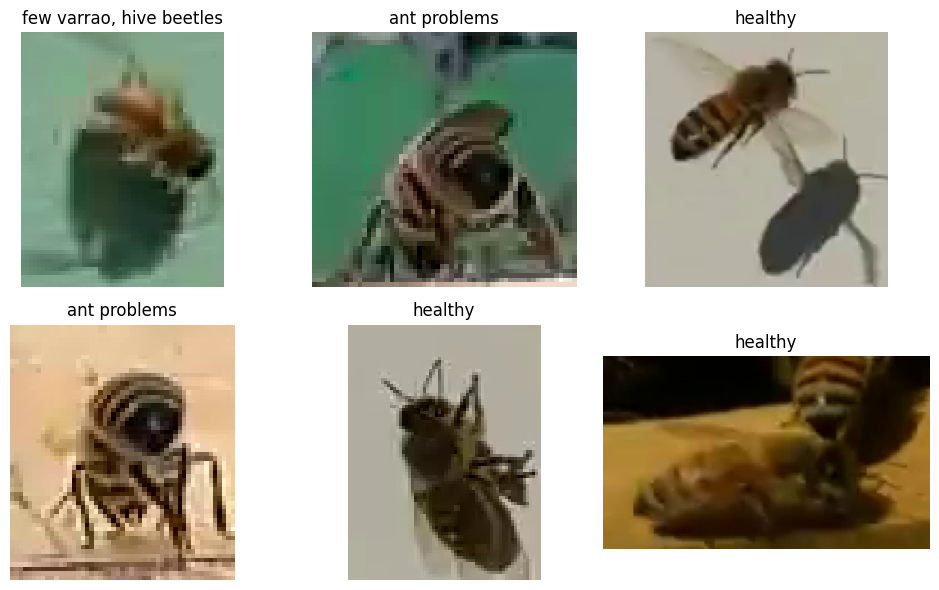

In [28]:
# Defined class names for reference
class_names = ["Varroa, Small Hive Beetles", "ant problems", "few varrao", "hive beetles",
"healthy", "hive being robbed", "missing queen"]

# Plot a 2x3 grid of random images from the dataset along with their labels
plt.figure(figsize=(10, 6))
for i in range(6):
    index = np.random.randint(0, len(x_train_images))
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_train_images[index])
    plt.title(y_train.iloc[index])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [1]:
# 1. Preprocess images
# - resize
# - normalize pixel values
# - convert list to numpy array for the training

from tensorflow.keras.utils import to_categorical

IMG_SIZE = 128
x_train_processed = np.array([
    np.array(Image.open(os.path.join("bee_imgs", x_train.iloc[i, 0])).resize((IMG_SIZE, IMG_SIZE))) / 255.0
    for i in range(len(x_train))
])

# Do the same for test images
x_test_images = [load_image(x_test.iloc[i, 0]) for i in range(len(x_test))]
x_test_processed = np.array([
    np.array(Image.open(os.path.join("bee_imgs", x_test.iloc[i, 0])).resize((IMG_SIZE, IMG_SIZE))) / 255.0
    for i in range(len(x_test))
])



ModuleNotFoundError: No module named 'tensorflow.python'

In [ ]:
# 2. Encode labels (y_train contains text labels, which NNs can use)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to one-hot encoding for neural network
y_train_categorical = to_categorical(y_train_encoded, num_classes)
y_test_categorical = to_categorical(y_test_encoded, num_classes)

print(f"x_train_processed shape: {x_train_processed.shape}")
print(f"y_train_categorical shape: {y_train_categorical.shape}")

In [ ]:
# 3. Build and Train the CNN model (RandomForest and SVM will be added later)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()